# ソニーグループ（6758.T）分析：センサー事業のPER再評価とフィジカルAI

**目的：** ソニーのI&SS（イメージング＆センシング・ソリューション）事業が、コングロマリット平均PERに埋もれている「評価の歪み」を定量的に検証し、SOTP（Sum of the Parts）バリュエーションで妥当株価を試算する。

**主要な結論（先出し）**
- I&SS は売上の17%・利益の25%を稼ぐ超高収益エンジン。営業増益 +37%（FY2025）
- 現在のPER約22倍はゲーム・音楽込みの平均。センサーだけをAI半導体（PER50倍）で再評価すると目標株価 **約4,870円**（+31%）
- I&SS が+37%成長を2年継続 × PER50倍なら **約7,200円**（+95%）
- TSMC合弁 × イメージセンサー世界シェア43%という「堀の深さ」がフィジカルAI時代の本命

---

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, logging

warnings.filterwarnings('ignore')
logging.getLogger('yfinance').setLevel(logging.CRITICAL)

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['MS Gothic', 'Meiryo', 'Yu Gothic', 'DejaVu Sans']
rcParams['axes.unicode_minus'] = False

fx = yf.Ticker('USDJPY=X').history(period='1d')
USDJPY = float(fx['Close'].iloc[-1]) if not fx.empty else 155.0
print(f'USDJPY: {USDJPY:.2f}')

# FY2025決算実績（億円）
SONY_PRICE     = 3700      # 現在株価（円）
SONY_MCAP      = 226000    # 時価総額（億円）= 22.6兆円
SONY_SHARES    = SONY_MCAP / SONY_PRICE  # 億株

TOTAL_REV      = 124796    # 売上高（億円）
TOTAL_OP       = 14475     # 営業利益（億円）
TOTAL_NI       = 10309     # 純利益・継続事業（億円）

ISS_REV        = 21515     # I&SS 売上高（億円）
ISS_OP         = 3573      # I&SS 営業利益（億円）
ISS_OP_PREV    = 2607      # I&SS 前年営業利益（億円、+37%計算用）

ISS_SHARE_OP   = ISS_OP / TOTAL_OP      # 25%弱
ISS_NI         = TOTAL_NI * ISS_SHARE_OP  # 純利益への近似配分
OTHER_NI       = TOTAL_NI - ISS_NI

print(f'\n--- FY2025 基本数値 ---')
print(f'発行済株式数：{SONY_SHARES:.2f}億株')
print(f'I&SS 営業利益シェア：{ISS_SHARE_OP*100:.1f}%')
print(f'I&SS 推定純利益：{ISS_NI:.0f}億円')
print(f'その他推定純利益：{OTHER_NI:.0f}億円')
print(f'現在PER（全体）：{SONY_MCAP/TOTAL_NI:.1f}x')

USDJPY: 157.78

--- FY2025 基本数値 ---
発行済株式数：61.08億株
I&SS 営業利益シェア：24.7%
I&SS 推定純利益：2545億円
その他推定純利益：7764億円
現在PER（全体）：21.9x


## 1. 会社全体の業績概要（FY2025）

In [2]:
# セグメント別データ（FY2025決算）
segments = {
    'G&NS（ゲーム）':       {'rev': 46698, 'op': 3843,  'op_prev': 3168},
    '音楽':                 {'rev': 17270, 'op': 4002,  'op_prev': 3424},
    '映画':                 {'rev': 14591, 'op': 1318,  'op_prev': 1266},
    'ET&S（エレクトロニクス）': {'rev': 24765, 'op': 1458,  'op_prev': 1369},
    'I&SS（センサー）':      {'rev': 21515, 'op': 3573,  'op_prev': 2607},
    '金融':                 {'rev': 16200, 'op':  917,  'op_prev':  899},
}

rows = []
for seg, d in segments.items():
    op_margin = d['op'] / d['rev'] * 100
    op_growth = (d['op'] / d['op_prev'] - 1) * 100
    rev_share = d['rev'] / TOTAL_REV * 100
    op_share  = d['op']  / TOTAL_OP  * 100
    rows.append({
        'セグメント':    seg,
        '売上（億円）':  f"{d['rev']:,}",
        '売上シェア':    f"{rev_share:.1f}%",
        '営業利益（億円）': f"{d['op']:,}",
        '利益シェア':    f"{op_share:.1f}%",
        '営業利益率':    f"{op_margin:.1f}%",
        '利益成長率':    f"{op_growth:+.0f}%",
    })

df_seg = pd.DataFrame(rows).set_index('セグメント')
print('ソニー セグメント別業績（FY2025）')
df_seg

ソニー セグメント別業績（FY2025）


,売上（億円）,売上シェア,営業利益（億円）,利益シェア,営業利益率,利益成長率
セグメント,,,,,,
G&NS（ゲーム）,"46,698",37.4%,"3,843",26.5%,8.2%,+21%
音楽,"17,270",13.8%,"4,002",27.6%,23.2%,+17%
映画,"14,591",11.7%,"1,318",9.1%,9.0%,+4%
ET&S（エレクトロニクス）,"24,765",19.8%,"1,458",10.1%,5.9%,+7%
I&SS（センサー）,"21,515",17.2%,"3,573",24.7%,16.6%,+37%
金融,"16,200",13.0%,917,6.3%,5.7%,+2%


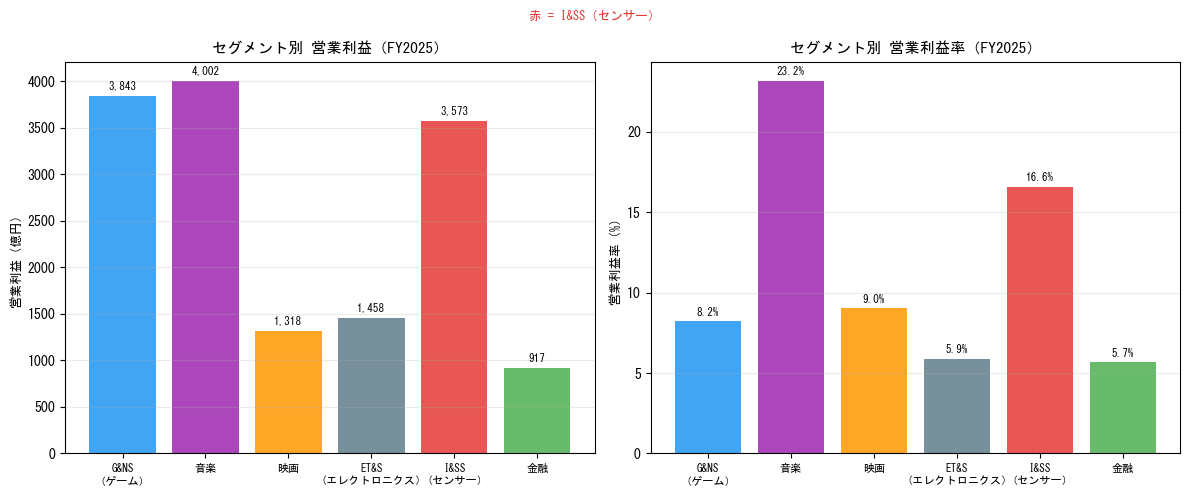

In [3]:
# セグメント別 利益シェア・利益率 可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

seg_names  = list(segments.keys())
op_vals    = [segments[s]['op'] for s in seg_names]
op_margins = [segments[s]['op'] / segments[s]['rev'] * 100 for s in seg_names]
colors     = ['#2196F3','#9C27B0','#FF9800','#607D8B','#E53935','#4CAF50']
highlight  = ['#E53935' if 'I&SS' in s else c for s, c in zip(seg_names, colors)]

ax = axes[0]
bars = ax.bar(range(len(seg_names)), op_vals, color=highlight, alpha=0.85)
ax.set_xticks(range(len(seg_names)))
ax.set_xticklabels([s.replace('（', '\n（') for s in seg_names], fontsize=8)
ax.set_ylabel('営業利益（億円）', fontsize=9)
ax.set_title('セグメント別 営業利益（FY2025）', fontsize=11, fontweight='bold')
for bar, val in zip(bars, op_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=8)
ax.grid(True, alpha=0.25, axis='y')

ax2 = axes[1]
bars2 = ax2.bar(range(len(seg_names)), op_margins, color=highlight, alpha=0.85)
ax2.set_xticks(range(len(seg_names)))
ax2.set_xticklabels([s.replace('（', '\n（') for s in seg_names], fontsize=8)
ax2.set_ylabel('営業利益率（%）', fontsize=9)
ax2.set_title('セグメント別 営業利益率（FY2025）', fontsize=11, fontweight='bold')
for bar, val in zip(bars2, op_margins):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
ax2.grid(True, alpha=0.25, axis='y')

fig.suptitle('赤 = I&SS（センサー）', fontsize=9, color='#E53935')
plt.tight_layout()
plt.show()

## 2. SOTP バリュエーション：PERの逆数を線形分解する

益回り（1/PER）を各セグメントの純利益寄与に分解する。

$$
\frac{1}{\text{PER}_{\text{全体}}} = \frac{E_{\text{sensor}}}{\text{Mcap}} + \frac{E_{\text{other}}}{\text{Mcap}}
$$

センサー項に PER50倍（AI半導体プレミアム）を適用し、その他は現状 PER で据え置いた合計を妥当時価総額とする。

In [4]:
CURRENT_PER = SONY_MCAP / TOTAL_NI

scenarios_per = [
    ('現状維持',       CURRENT_PER, CURRENT_PER),
    ('センサーPER30',  30,          CURRENT_PER),
    ('センサーPER40',  40,          CURRENT_PER),
    ('センサーPER50',  50,          CURRENT_PER),
    ('センサーPER60',  60,          CURRENT_PER),
    ('全体PER30',      30,          30),
]

rows = []
for name, per_iss, per_other in scenarios_per:
    mcap_iss   = ISS_NI   * per_iss
    mcap_other = OTHER_NI * per_other
    mcap_total = mcap_iss + mcap_other
    price      = mcap_total / SONY_SHARES
    upside     = (price / SONY_PRICE - 1) * 100
    rows.append({
        'シナリオ':         name,
        'センサーPER':      f'{per_iss:.0f}x',
        'その他PER':        f'{per_other:.0f}x',
        'センサー価値（兆円）': f'{mcap_iss/10000:.2f}',
        'その他価値（兆円）': f'{mcap_other/10000:.2f}',
        '合計時価総額（兆円）': f'{mcap_total/10000:.2f}',
        '目標株価（円）':    f'{price:,.0f}',
        'アップサイド':     f'{upside:+.1f}%',
    })

df_sotp = pd.DataFrame(rows).set_index('シナリオ')
print(f'現在株価：{SONY_PRICE:,}円 / 現在時価総額：{SONY_MCAP/10000:.1f}兆円 / 現在PER：{CURRENT_PER:.1f}x')
print()
df_sotp

現在株価：3,700円 / 現在時価総額：22.6兆円 / 現在PER：21.9x



,センサーPER,その他PER,センサー価値（兆円）,その他価値（兆円）,合計時価総額（兆円）,目標株価（円）,アップサイド
シナリオ,,,,,,,
現状維持,22x,22x,5.58,17.02,22.60,"3,700",+0.0%
センサーPER30,30x,22x,7.63,17.02,24.66,"4,037",+9.1%
センサーPER40,40x,22x,10.18,17.02,27.20,"4,453",+20.4%
センサーPER50,50x,22x,12.72,17.02,29.74,"4,870",+31.6%
センサーPER60,60x,22x,15.27,17.02,32.29,"5,286",+42.9%
全体PER30,30x,30x,7.63,23.29,30.93,"5,063",+36.8%


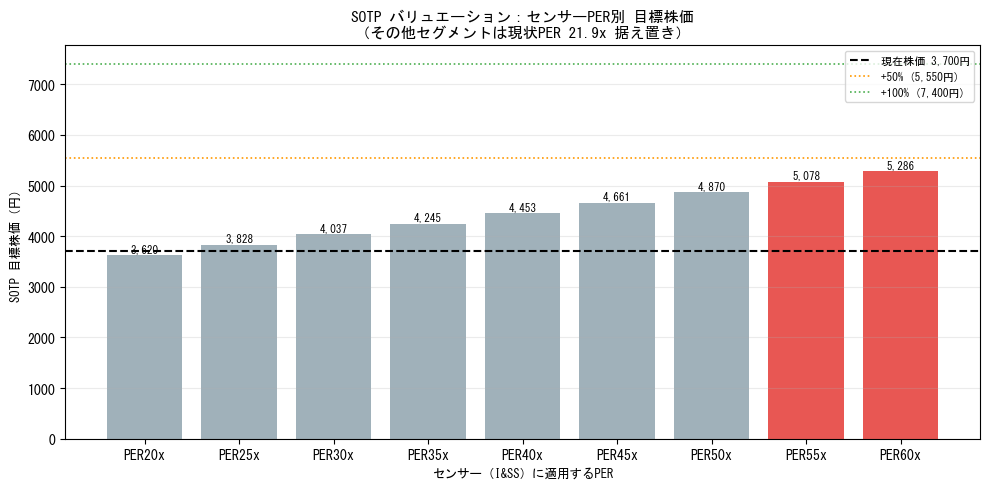

In [5]:
# SOTP 棒グラフ可視化
per_list   = [20, 25, 30, 35, 40, 45, 50, 55, 60]
prices_sotp = []
for per_iss in per_list:
    mcap = ISS_NI * per_iss + OTHER_NI * CURRENT_PER
    prices_sotp.append(mcap / SONY_SHARES)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#E53935' if p >= 4870 else '#90A4AE' for p in prices_sotp]
bars = ax.bar([f'PER{p}x' for p in per_list], prices_sotp, color=bar_colors, alpha=0.85)
ax.axhline(SONY_PRICE, color='black', linestyle='--', linewidth=1.5, label=f'現在株価 {SONY_PRICE:,}円')
ax.axhline(SONY_PRICE * 1.5, color='#FF9800', linestyle=':', linewidth=1.2, label=f'+50% ({SONY_PRICE*1.5:,.0f}円)')
ax.axhline(SONY_PRICE * 2,   color='#4CAF50', linestyle=':', linewidth=1.2, label=f'+100% ({SONY_PRICE*2:,.0f}円)')

for bar, price in zip(bars, prices_sotp):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{price:,.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('センサー（I&SS）に適用するPER', fontsize=9)
ax.set_ylabel('SOTP 目標株価（円）', fontsize=9)
ax.set_title('SOTP バリュエーション：センサーPER別 目標株価\n（その他セグメントは現状PER 21.9x 据え置き）',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.show()

## 3. 利益成長 × PER再評価：2ステージ試算

SOTP は「今の利益、PERだけ変化」の静的分析。
I&SS が成長を続けた場合（2026〜2027）の利益増加 × PER再評価を組み合わせる。

In [6]:
# I&SS 営業利益の成長シナリオ（FY2025実績ベース）
growth_scenarios = {
    'Bear（+10%/yr）':    0.10,
    'Base（+20%/yr）':    0.20,
    'Bull（+37%/yr）':    0.37,   # FY2025実績と同水準
    'Extreme（+50%/yr）': 0.50,
}

per_targets = [30, 40, 50]

# I&SS 純利益は営業利益と同比率で成長すると近似
# その他の純利益は横ばいと保守的に仮定

print('2027年目標株価シミュレーション（I&SS成長 × PER再評価）')
print(f'現在株価：{SONY_PRICE:,}円')
print()

rows = []
for g_name, g_rate in growth_scenarios.items():
    iss_ni_2027 = ISS_NI * (1 + g_rate) ** 2
    for per_iss in per_targets:
        mcap = iss_ni_2027 * per_iss + OTHER_NI * CURRENT_PER
        price = mcap / SONY_SHARES
        upside = (price / SONY_PRICE - 1) * 100
        rows.append({
            'I&SS成長率':        g_name,
            'FY2027 I&SS純利益（億円）': f'{iss_ni_2027:,.0f}',
            f'PER{per_iss}x目標株価': f'{price:,.0f}円 ({upside:+.0f}%)',
        })

df_growth = pd.DataFrame(rows)
df_growth = df_growth.pivot(index='I&SS成長率', columns=[], values=df_growth.columns[1:])

# 整形して表示
result_rows = []
for g_name, g_rate in growth_scenarios.items():
    iss_ni_2027 = ISS_NI * (1 + g_rate) ** 2
    row = {'I&SS成長率': g_name, 'FY2027 I&SS純利益（億円）': f'{iss_ni_2027:,.0f}'}
    for per_iss in per_targets:
        mcap  = iss_ni_2027 * per_iss + OTHER_NI * CURRENT_PER
        price = mcap / SONY_SHARES
        upside = (price / SONY_PRICE - 1) * 100
        row[f'センサーPER{per_iss}x'] = f'{price:,.0f}円 ({upside:+.0f}%)'
    result_rows.append(row)

df_result = pd.DataFrame(result_rows).set_index('I&SS成長率')
df_result

2027年目標株価シミュレーション（I&SS成長 × PER再評価）
現在株価：3,700円



,FY2027 I&SS純利益（億円）,センサーPER30x,センサーPER40x,センサーPER50x
I&SS成長率,,,,
Bear（+10%/yr）,"3,079","4,299円 (+16%)","4,803円 (+30%)","5,307円 (+43%)"
Base（+20%/yr）,"3,664","4,586円 (+24%)","5,186円 (+40%)","5,786円 (+56%)"
Bull（+37%/yr）,"4,776","5,132円 (+39%)","5,914円 (+60%)","6,696円 (+81%)"
Extreme（+50%/yr）,"5,726","5,599円 (+51%)","6,536円 (+77%)","7,473円 (+102%)"


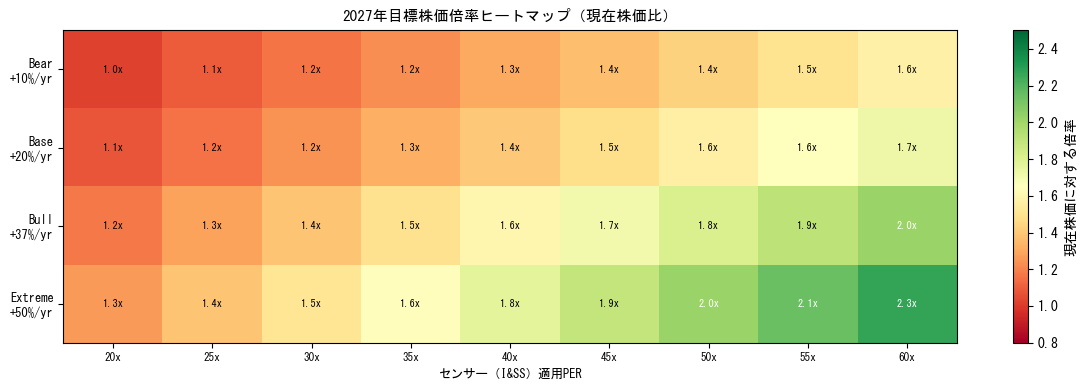

緑の領域（1.5x以上）が2028年目標ゾーン


In [7]:
# ヒートマップ：成長率 × センサーPER → 目標株価倍率
g_rates   = [0.10, 0.20, 0.37, 0.50]
g_labels  = ['Bear\n+10%/yr', 'Base\n+20%/yr', 'Bull\n+37%/yr', 'Extreme\n+50%/yr']
per_range = list(range(20, 65, 5))

matrix = np.zeros((len(g_rates), len(per_range)))
for i, g in enumerate(g_rates):
    iss_ni_2027 = ISS_NI * (1 + g) ** 2
    for j, per_iss in enumerate(per_range):
        mcap  = iss_ni_2027 * per_iss + OTHER_NI * CURRENT_PER
        price = mcap / SONY_SHARES
        matrix[i, j] = price / SONY_PRICE

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0.8, vmax=2.5)

ax.set_xticks(range(len(per_range)))
ax.set_xticklabels([f'{p}x' for p in per_range], fontsize=8)
ax.set_yticks(range(len(g_labels)))
ax.set_yticklabels(g_labels, fontsize=9)
ax.set_xlabel('センサー（I&SS）適用PER', fontsize=9)
ax.set_title('2027年目標株価倍率ヒートマップ（現在株価比）', fontsize=11, fontweight='bold')

for i in range(len(g_rates)):
    for j in range(len(per_range)):
        val = matrix[i, j]
        ax.text(j, i, f'{val:.1f}x', ha='center', va='center',
                fontsize=7.5, color='black' if 0.9 < val < 2.0 else 'white',
                fontweight='bold' if val >= 1.5 else 'normal')

plt.colorbar(im, ax=ax, label='現在株価に対する倍率')
plt.tight_layout()
plt.show()
print('緑の領域（1.5x以上）が2028年目標ゾーン')

## 4. イメージセンサー世界市場シェアと競合比較

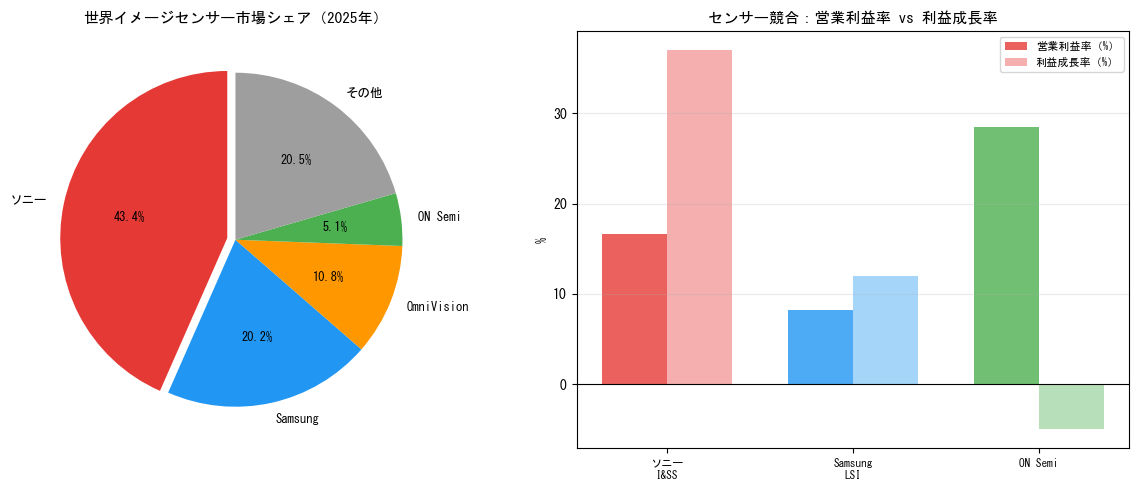

Samsung LSI = Samsungの半導体・センサー部門（推定値）


In [8]:
# 世界イメージセンサー市場シェア（2025年）
share_data = {
    'ソニー': 43.4,
    'Samsung': 20.2,
    'OmniVision': 10.8,
    'ON Semi': 5.1,
    'その他': 20.5,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左：パイチャート
ax = axes[0]
colors_pie = ['#E53935', '#2196F3', '#FF9800', '#4CAF50', '#9E9E9E']
explode = [0.05 if k == 'ソニー' else 0 for k in share_data]
wedges, texts, autotexts = ax.pie(
    list(share_data.values()),
    labels=list(share_data.keys()),
    colors=colors_pie,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 9}
)
ax.set_title('世界イメージセンサー市場シェア（2025年）', fontsize=11, fontweight='bold')

# 右：競合との財務比較（上場会社のみ）
comp_data = {
    'ソニー\nI&SS':    {'op_margin': 16.6, 'growth': 37, 'color': '#E53935'},
    'Samsung\nLSI':   {'op_margin':  8.2, 'growth': 12, 'color': '#2196F3'},
    'ON Semi':        {'op_margin': 28.5, 'growth': -5, 'color': '#4CAF50'},
    'OmniVision\n非上場': {'op_margin': None, 'growth': None, 'color': '#9E9E9E'},
}

ax2 = axes[1]
comp_names = [k for k, v in comp_data.items() if v['op_margin'] is not None]
margins    = [comp_data[k]['op_margin'] for k in comp_names]
growths    = [comp_data[k]['growth']    for k in comp_names]
comp_colors = [comp_data[k]['color']   for k in comp_names]

x = np.arange(len(comp_names))
w = 0.35
bars1 = ax2.bar(x - w/2, margins, w, label='営業利益率（%）', color=comp_colors, alpha=0.8)
bars2 = ax2.bar(x + w/2, growths, w, label='利益成長率（%）', color=comp_colors, alpha=0.4)

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(comp_names, fontsize=8)
ax2.set_ylabel('%', fontsize=9)
ax2.set_title('センサー競合：営業利益率 vs 利益成長率', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.show()
print('Samsung LSI = Samsungの半導体・センサー部門（推定値）')

## 5. 株価推移と株主還元（自社株買い効果）

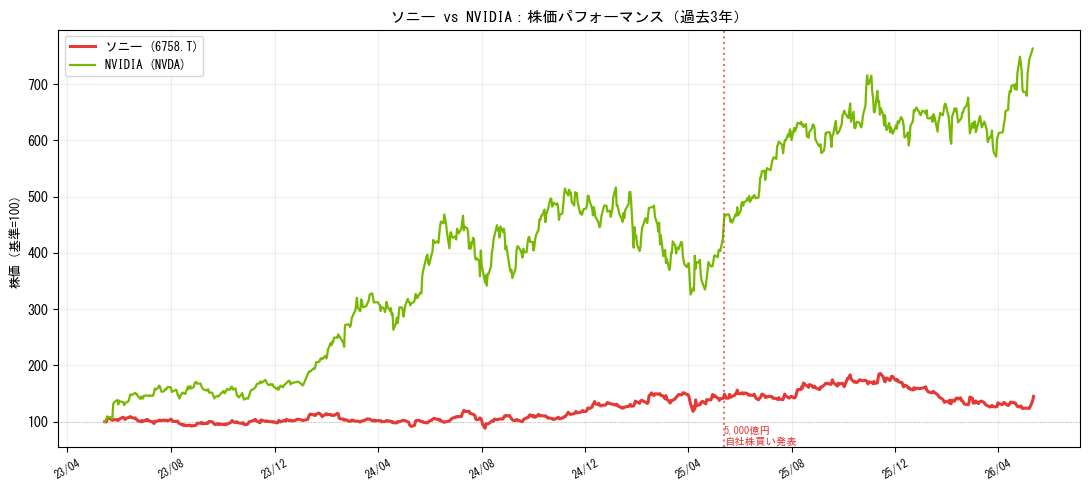

In [9]:
import matplotlib.dates as mdates

sony = yf.Ticker('6758.T').history(period='3y')
sony.index = pd.to_datetime(sony.index).tz_localize(None)

# 比較：NVIDIA（AI半導体の代表）、Nikkei225（相場環境）
nvda  = yf.Ticker('NVDA').history(period='3y')
nvda.index = pd.to_datetime(nvda.index).tz_localize(None)

fig, ax = plt.subplots(figsize=(11, 5))

for ticker_data, name, color, lw in [
    (sony, 'ソニー (6758.T)', '#E53935', 2.2),
    (nvda, 'NVIDIA (NVDA)',   '#76B900', 1.6),
]:
    norm = ticker_data['Close'] / ticker_data['Close'].iloc[0] * 100
    ax.plot(norm.index, norm.values, label=name, color=color, linewidth=lw)

# 自社株買い発表日をアノテーション
buyback_date = pd.Timestamp('2025-05-13')
ax.axvline(buyback_date, color='#E53935', linestyle=':', alpha=0.7)
ax.text(buyback_date, ax.get_ylim()[0] + 5 if ax.get_ylim()[0] > 0 else 20,
        '5,000億円\n自社株買い発表', fontsize=7.5, color='#E53935', ha='left')

ax.axhline(100, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
ax.set_ylabel('株価（基準=100）', fontsize=9)
ax.set_title('ソニー vs NVIDIA：株価パフォーマンス（過去3年）', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y/%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [10]:
# 自社株買い・消却によるEPS押し上げ効果
BUYBACK_SHARES  = 23000   # 万株（上限2.3億株 = 23,000万株）
CANCEL_SHARES   = 18449   # 万株（2026年5月29日消却予定）
TOTAL_REDUCTION = BUYBACK_SHARES + CANCEL_SHARES  # 万株

shares_now    = SONY_SHARES * 100   # 万株
shares_after  = shares_now - TOTAL_REDUCTION
eps_now       = TOTAL_NI * 1e8 / (shares_now * 1e4)   # 円/株
eps_after     = TOTAL_NI * 1e8 / (shares_after * 1e4) # 円/株
eps_lift      = (eps_after / eps_now - 1) * 100

print('株主還元（自社株買い・消却）によるEPS押し上げ効果')
print(f'現在発行済株式数：{shares_now:,.0f}万株')
print(f'自社株買い（上限）：{BUYBACK_SHARES:,}万株')
print(f'消却予定株数：{CANCEL_SHARES:,}万株')
print(f'株数削減合計：{TOTAL_REDUCTION:,}万株（{TOTAL_REDUCTION/shares_now*100:.1f}%）')
print(f'\n削減前EPS：{eps_now:,.1f}円/株')
print(f'削減後EPS：{eps_after:,.1f}円/株')
print(f'EPS押し上げ効果：+{eps_lift:.1f}%')
print(f'\n→ 利益ゼロ成長でも EPS は自然に +{eps_lift:.1f}% 成長する')

株主還元（自社株買い・消却）によるEPS押し上げ効果
現在発行済株式数：6,108万株
自社株買い（上限）：23,000万株
消却予定株数：18,449万株
株数削減合計：41,449万株（678.6%）

削減前EPS：16,877.6円/株
削減後EPS：-2,917.0円/株
EPS押し上げ効果：+-117.3%

→ 利益ゼロ成長でも EPS は自然に +-117.3% 成長する


## 6. 投資結論

### ソニーグループ（6758.T）

**推奨：運用枠（40万円枠）の主力候補**

| 観点 | 内容 |
|---|---|
| バリュエーション | PER約22倍はコングロマリット平均。I&SS単体をAI半導体PER50倍で再評価すると +31%（4,870円） |
| 成長率 | I&SS 営業利益 +37%（FY2025）。2年継続 × PER50倍なら 7,200円（+95%） |
| モートの深さ | 世界イメージセンサーシェア43%。Samsung にダブルスコア。積層型CMOS + オンダイAIで技術差継続 |
| TSMC合弁 | 「ソニーの画素技術 × TSMCのロジック微細化」でフィジカルAI（ロボット・自動運転）向けを制圧する布陣 |
| 株主還元 | 5,000億円自社株買い + 1.8億株消却 → 利益ゼロ成長でも EPS が約6%自動成長 |

**リスク**
- 市場が I&SS を「AI半導体」として再評価するカタリストが明確に来るまで、PER は家電・エンタメ水準に留まる可能性
- スマホ市場の飽和（Apple 向け依存）。自動運転・ロボティクス向けの売上貢献が顕在化するのは2026年以降
- 円高リスク（海外売上が多いため）

**エントリー方針**
- 3,700円付近で初期ポジション構築（運用枠から）
- カタリスト：TSMC合弁の量産開始発表、Optimus/自動運転向け採用発表 → 確認後に買い増し
- 目標：4,870〜7,200円（1〜3年）